In [7]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [8]:
import glob
files = glob.glob("*.csv")   # looks for CSVs in current folder
print(files)


['202501-divvy-tripdata.csv', '202502-divvy-tripdata.csv', '202503-divvy-tripdata.csv', '202504-divvy-tripdata.csv', '202505-divvy-tripdata.csv', '202506-divvy-tripdata.csv', '202507-divvy-tripdata.csv', '202508-divvy-tripdata.csv', '202509-divvy-tripdata.csv', '202510-divvy-tripdata.csv', '202511-divvy-tripdata.csv', '202512-divvy-tripdata.csv']


In [9]:
import pandas as pd

df_list = [pd.read_csv(f) for f in files]
cyclistic = pd.concat(df_list, ignore_index=True)

cyclistic.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member


In [10]:
cyclistic['started_at'] = pd.to_datetime(cyclistic['started_at'])
cyclistic['ended_at']   = pd.to_datetime(cyclistic['ended_at'])
cyclistic['trip_duration_minutes'] = (cyclistic['ended_at'] - cyclistic['started_at']).dt.total_seconds()/60

cyclistic['month'] = cyclistic['started_at'].dt.month_name()
cyclistic['day_of_week'] = cyclistic['started_at'].dt.day_name()
cyclistic['hour'] = cyclistic['started_at'].dt.hour

cyclistic['season'] = cyclistic['started_at'].dt.month.map({
    12:"Winter",1:"Winter",2:"Winter",
    3:"Spring",4:"Spring",5:"Spring",
    6:"Summer",7:"Summer",8:"Summer",
    9:"Fall",10:"Fall",11:"Fall"
})


In [11]:
cyclistic = cyclistic.drop_duplicates(subset="ride_id")
cyclistic = cyclistic.dropna(subset=["started_at","ended_at","start_station_name","end_station_name"])
cyclistic = cyclistic[cyclistic['trip_duration_minutes'] >= 0]


In [12]:
# riders_by_member_type

C:\Users\soma\AppData\Local\Temp\ipykernel_7108\3208723149.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cyclistic, x="member_casual", palette="Set2")


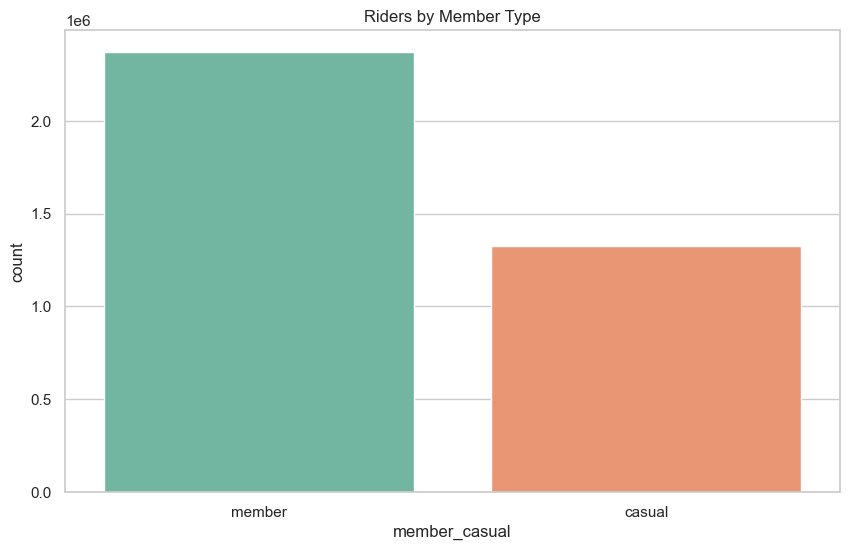

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=cyclistic, x="member_casual", palette="Set2")
plt.title("Riders by Member Type")
plt.show()


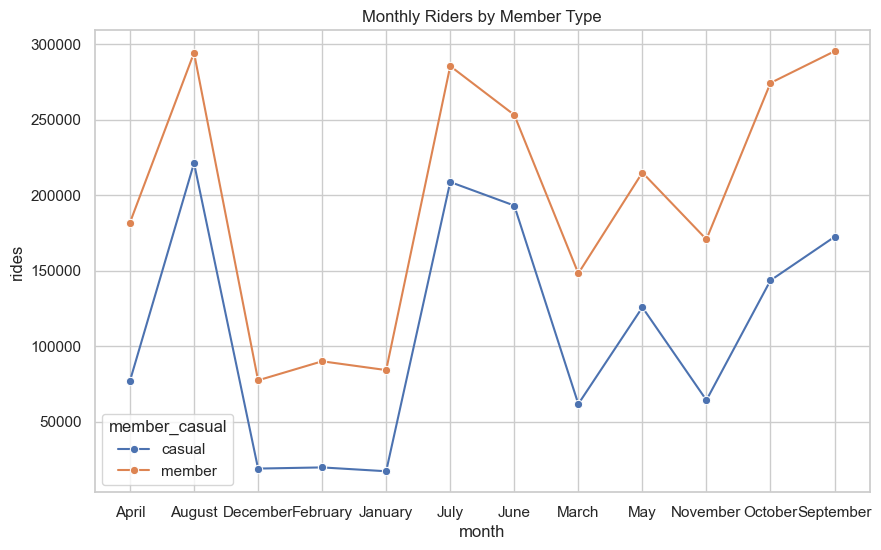

In [14]:
#monthly_rider
monthly = cyclistic.groupby(["month","member_casual"]).size().reset_index(name="rides")
sns.lineplot(data=monthly, x="month", y="rides", hue="member_casual", marker="o")
plt.title("Monthly Riders by Member Type")
plt.show()


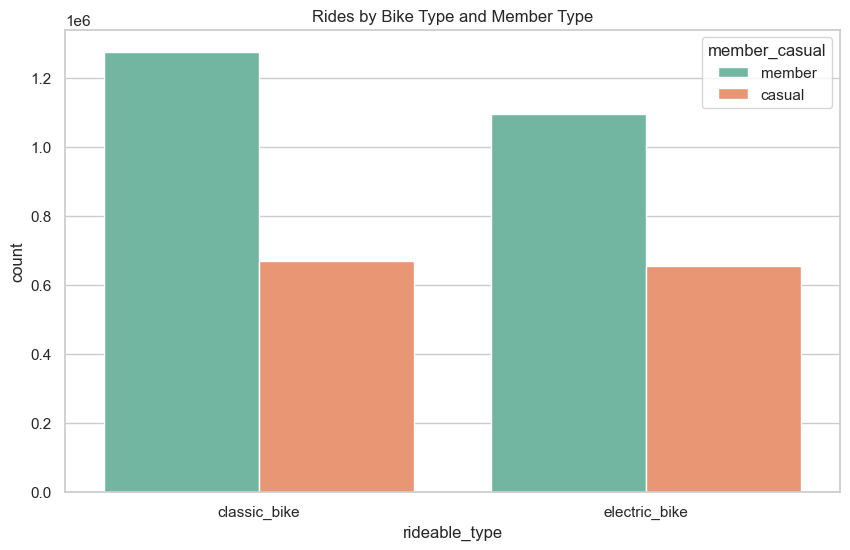

In [15]:
#rider_by_member_type_and_bike_type
sns.countplot(data=cyclistic, x="rideable_type", hue="member_casual", palette="Set2")
plt.title("Rides by Bike Type and Member Type")
plt.show()


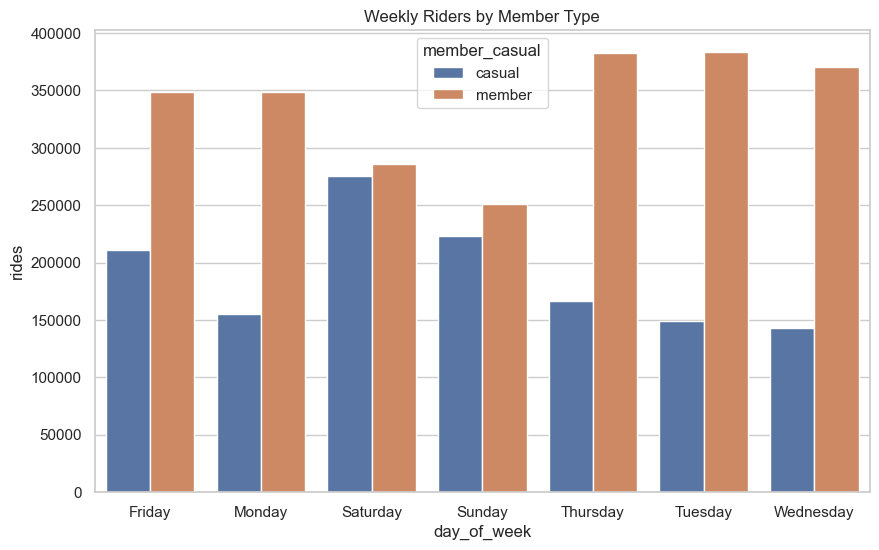

In [16]:
#weekly_riders
weekly = cyclistic.groupby(["day_of_week","member_casual"]).size().reset_index(name="rides")
sns.barplot(data=weekly, x="day_of_week", y="rides", hue="member_casual")
plt.title("Weekly Riders by Member Type")
plt.show()


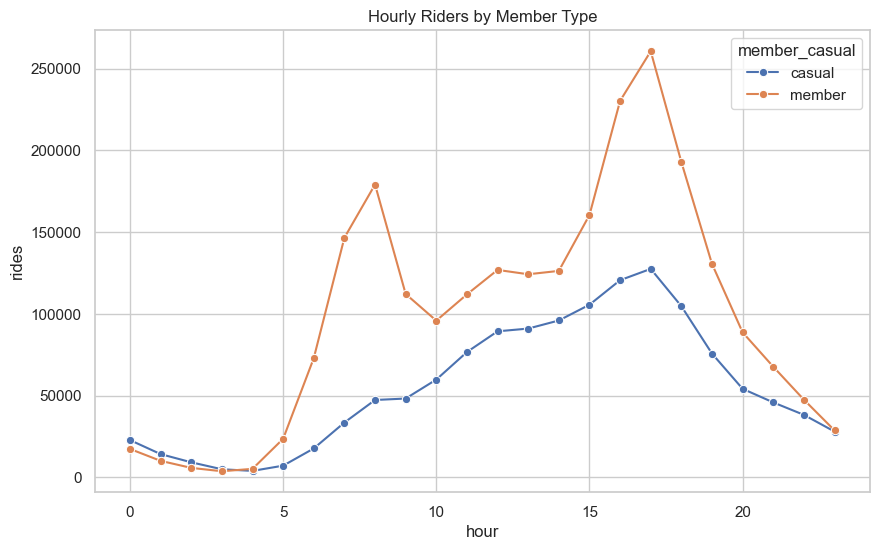

In [17]:
#hourly_riders
hourly = cyclistic.groupby(["hour","member_casual"]).size().reset_index(name="rides")
sns.lineplot(data=hourly, x="hour", y="rides", hue="member_casual", marker="o")
plt.title("Hourly Riders by Member Type")
plt.show()


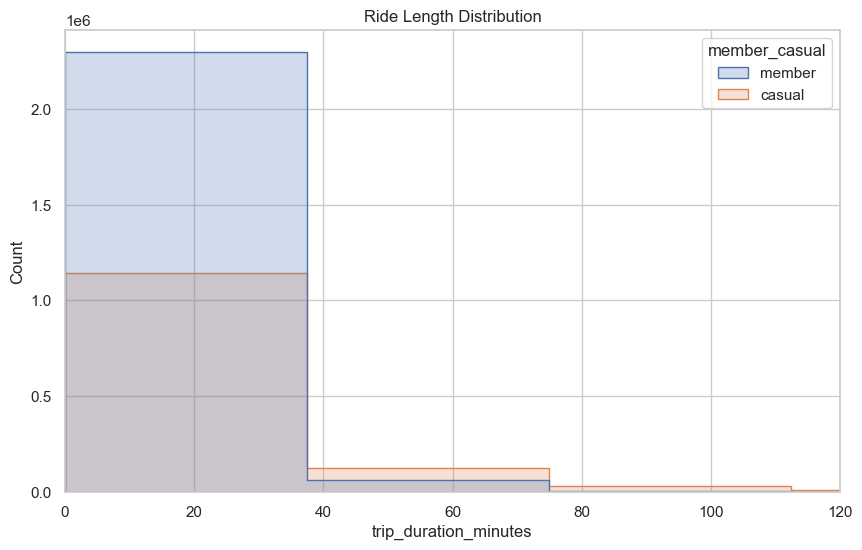

In [18]:
#ride_length_distribution
sns.histplot(data=cyclistic, x="trip_duration_minutes", hue="member_casual", bins=40, element="step")
plt.xlim(0,120)
plt.title("Ride Length Distribution")
plt.show()


C:\Users\soma\AppData\Local\Temp\ipykernel_7108\585215189.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket = cyclistic.groupby(["duration_bucket","member_casual"]).size().reset_index(name="rides")


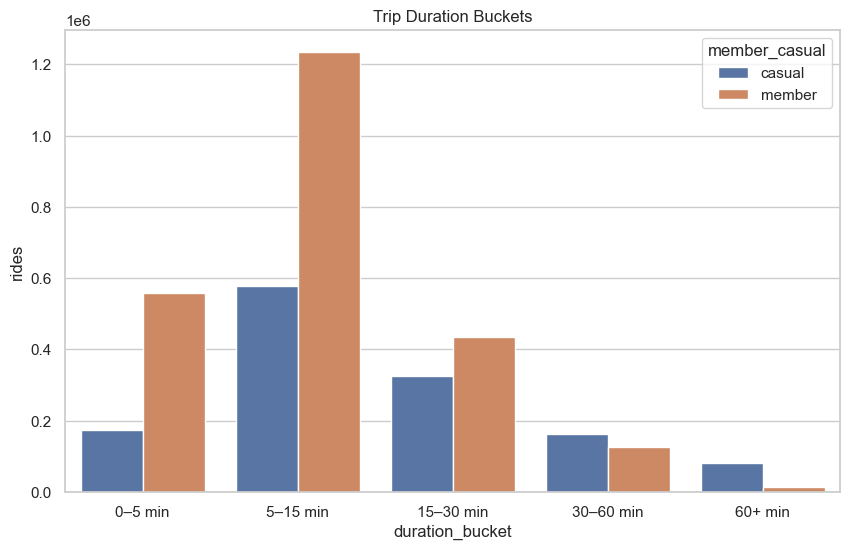

In [19]:
#trip_duration
bins = [0,5,15,30,60,9999]
labels = ["0–5 min","5–15 min","15–30 min","30–60 min","60+ min"]
cyclistic['duration_bucket'] = pd.cut(cyclistic['trip_duration_minutes'], bins=bins, labels=labels)

bucket = cyclistic.groupby(["duration_bucket","member_casual"]).size().reset_index(name="rides")
sns.barplot(data=bucket, x="duration_bucket", y="rides", hue="member_casual")
plt.title("Trip Duration Buckets")
plt.show()


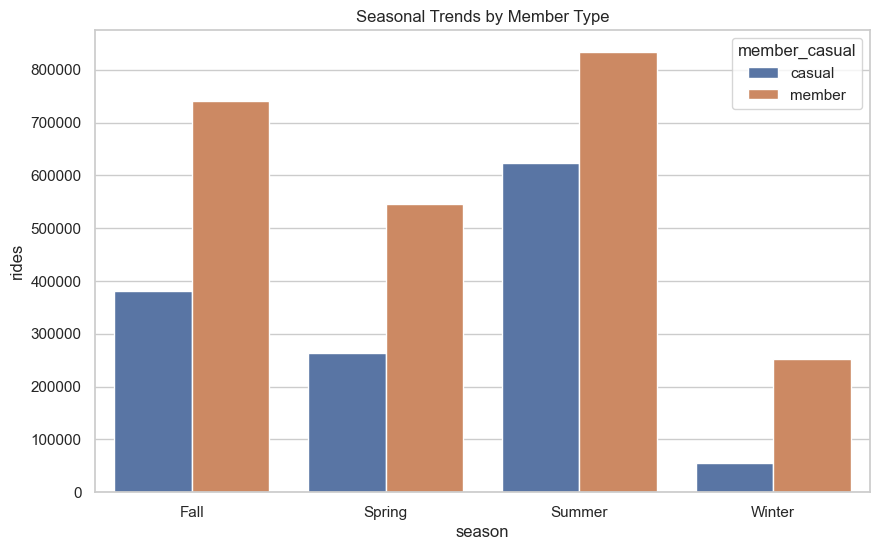

In [20]:
#seasonal_trends
seasonal = cyclistic.groupby(["season","member_casual"]).size().reset_index(name="rides")
sns.barplot(data=seasonal, x="season", y="rides", hue="member_casual")
plt.title("Seasonal Trends by Member Type")
plt.show()


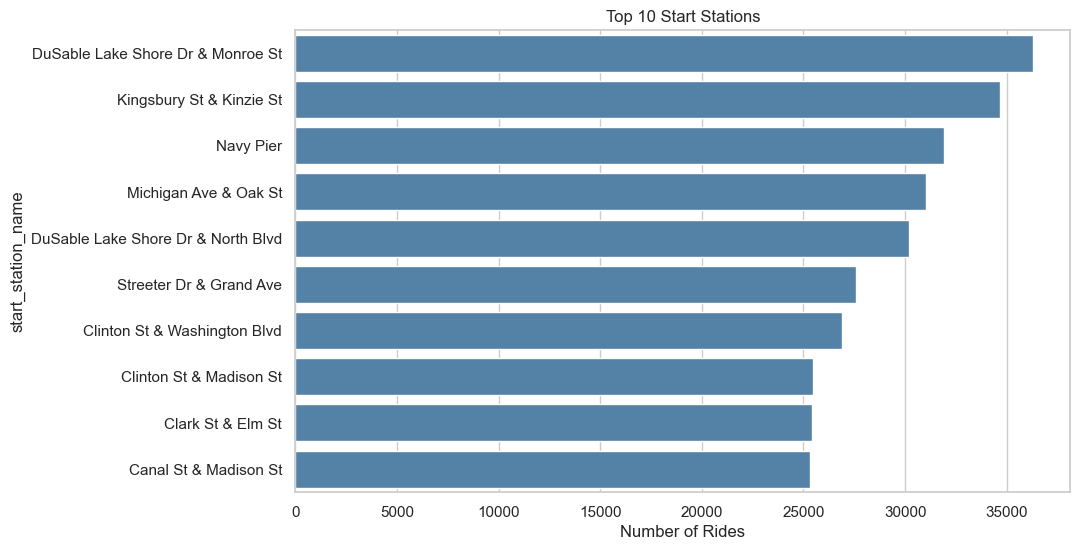

In [21]:
#stational_analysis
top_stations = cyclistic['start_station_name'].value_counts().head(10)
sns.barplot(x=top_stations.values, y=top_stations.index, color="steelblue")
plt.title("Top 10 Start Stations")
plt.xlabel("Number of Rides")
plt.show()


In [22]:
#KPI_dashboard
total_rides = len(cyclistic)
avg_duration = cyclistic['trip_duration_minutes'].mean()
peak_month = cyclistic['month'].value_counts().idxmax()
member_split = cyclistic['member_casual'].value_counts(normalize=True)*100

print("=== KPI Dashboard ===")
print(f"Total Rides: {total_rides}")
print(f"Average Duration (minutes): {avg_duration:.2f}")
print(f"Peak Month: {peak_month}")
print("Member vs Casual Split (%):")
print(member_split)


=== KPI Dashboard ===
Total Rides: 3693235
Average Duration (minutes): 15.92
Peak Month: August
Member vs Casual Split (%):
member_casual
member    64.170761
casual    35.829239
Name: proportion, dtype: float64
